# 04 · Mapping meaning: generated documents, PCA and UMAP

In notebook 03 we *measured* semantic similarity. Now we want to **see** it.

Along the way this notebook quietly teaches two things you need later:

* **LLM-generated synthetic data.** Getting a labelled corpus used to take
  weeks. We will produce one in two minutes, and then talk honestly about what
  is wrong with it.
* **Dimensionality reduction.** 768 dimensions → 2, so a human can look at it.
  PCA and UMAP answer *different questions*; knowing which is which will save
  you from over-reading a pretty picture.

Plan:

1. use an LLM to write ~12 short documents for each of 6 categories
2. embed all of them
3. project to 2D with **PCA** (linear, global, fast, interpretable)
4. project to 2D with **UMAP** (non-linear, local, prettier, trickier)
5. measure whether the structure is real, instead of trusting our eyes

In [ ]:
%pip install -q -r ../requirements.txt

In [1]:
import pathlib
import sys

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "common").is_dir()
)
sys.path.insert(0, str(ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common.workshop_setup import DATA_DIR, describe_model, get_chat_model, get_embeddings, timer

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1 · Generating a labelled corpus with an LLM

We ask the model for short, realistic sentences per category. Two techniques
worth stealing:

* **Ask for JSON and parse it.** Free-form text needs regex archaeology.
  (Notebook 06 shows the bulletproof version of this.)
* **Turn the temperature up.** For synthetic data, we *want* variety. At
  `temperature=0` you would get twelve paraphrases of the same sentence.

In [2]:
CATEGORIES = ["healthcare", "sport", "education", "finance", "climate science", "cooking"]
DOCS_PER_CATEGORY = 12

generation_prompt = """Write {n} short, varied, realistic sentences about {category}.

Rules:
- one or two sentences each, 12-30 words
- vary the subtopic, the tone and the vocabulary
- do NOT mention the word "{category}" itself
- return ONLY a JSON array of strings, nothing else

JSON array:"""

In [3]:
import re


def parse_sentences(text: str) -> list[str]:
    """Get a list of sentences out of whatever the model actually sent.

    Small models mis-format constantly: ```json fences, a chatty preamble, a
    truncated array, numbered lists instead of JSON. So we try three
    increasingly desperate strategies. (Notebook 06 shows the *proper* fix --
    `with_structured_output` -- which makes all of this unnecessary.)
    """
    text = text.strip()

    # Strategy 1: a real JSON array somewhere in the text.
    start, end = text.find("["), text.rfind("]")
    if start != -1 and end > start:
        try:
            items = json.loads(text[start : end + 1])
            if isinstance(items, list) and items:
                out = []
                for item in items:
                    # Models sometimes return [{"text": "..."}] instead of
                    # ["..."]. Take the first string value we find.
                    if isinstance(item, dict):
                        item = next(
                            (v for v in item.values() if isinstance(v, str)), ""
                        )
                    if str(item).strip():
                        out.append(str(item).strip())
                if out:
                    return out
        except json.JSONDecodeError:
            pass  # truncated or trailing comma -- fall through

    # Strategy 2: every double-quoted string of a plausible length.
    quoted = [m.strip() for m in re.findall(r'"([^"\n]{25,400})"', text)]
    if len(quoted) >= 3:
        return quoted

    # Strategy 3: line-based, stripping bullets and numbering.
    lines = []
    for line in text.splitlines():
        line = re.sub(r'^\s*(?:[-*\u2022]|\d+[.)])\s*', "", line).strip().strip('",')
        if len(line) > 25 and not line.startswith(("```", "{", "[", "Here")):
            lines.append(line)
    if len(lines) >= 3:
        return lines

    raise ValueError(f"could not parse: {text[:150]!r}")


CACHE = DATA_DIR / "generated_corpus.json"


def build_corpus(force: bool = False) -> pd.DataFrame:
    """Generate (or load from cache) the labelled corpus."""
    if CACHE.exists() and not force:
        print(f"Loading cached corpus from {CACHE}")
        return pd.DataFrame(json.loads(CACHE.read_text()))

    # Generous max_tokens: 12 sentences of JSON is easily 600+ tokens, and a
    # truncated array is unparseable.
    llm = get_chat_model(temperature=0.9, max_tokens=2000)
    print("generating with", describe_model(llm))

    records = []
    for category in CATEGORIES:
        prompt = generation_prompt.format(n=DOCS_PER_CATEGORY, category=category)
        for attempt in range(3):                      # LLMs mis-format sometimes
            try:
                raw = llm.invoke(prompt).content
                sentences = parse_sentences(raw)
                if len(sentences) < 4:
                    raise ValueError(f"only {len(sentences)} sentences")
                break
            except Exception as exc:
                print(f"  retry {category} ({attempt + 1}/3): {type(exc).__name__}")
        else:
            print(f"  ⚠ giving up on {category}")
            continue
        records += [{"category": category, "text": s} for s in sentences[:DOCS_PER_CATEGORY]]
        print(f"  ✅ {category}: {len(sentences[:DOCS_PER_CATEGORY])} documents")

    CACHE.write_text(json.dumps(records, indent=2, ensure_ascii=False))
    print(f"\nSaved {len(records)} documents to {CACHE}")
    return pd.DataFrame(records)


with timer("corpus"):
    corpus = build_corpus()

# A small model occasionally fails a category entirely. Drop those rather than
# carrying an empty group into the maths later.
CATEGORIES = [c for c in CATEGORIES if (corpus.category == c).sum() >= 3]
corpus = corpus[corpus.category.isin(CATEGORIES)].reset_index(drop=True)

print(f"\n{len(corpus)} documents across {len(CATEGORIES)} categories")
print(corpus.groupby("category").size().to_string())
if len(CATEGORIES) < 6:
    print("\n(Some categories failed to generate -- that is the small model\n"
          " mis-formatting its JSON. Re-run with build_corpus(force=True),\n"
          " or switch WORKSHOP_BACKEND to litellm, or just carry on.)")

Loading cached corpus from /home/sofiane/Downloads/IMPRS_LLM_Workshop/data/generated_corpus.json
[corpus: 0.01s]

62 documents across 6 categories
category
climate science    12
cooking            12
education          12
finance            10
healthcare          5
sport              11


In [4]:
# Look at the data before you model it. Always.
for category in corpus.category.unique():
    sample = corpus[corpus.category == category].text.iloc[0]
    print(f"[{category:<16}] {sample[:110]}")

[healthcare      ] A nurse checks vital signs on every patient during their morning shift.
[sport           ] The batter swung at the pitch with incredible focus.
[education       ] The ancient library stood like a silent guardian over centuries of forgotten stories.
[finance         ] Investors often notice when market prices fluctuate due to global news events.
[climate science ] {'text': 'Global temperature anomalies have accelerated since 2015 due to persistent solar variability.', 'wor
[cooking         ] You stir gently to avoid disturbing the delicate sauce resting on top.


> **Re-generate?** Delete `data/generated_corpus.json`, or call
> `build_corpus(force=True)`. The cache exists so nobody waits three minutes
> twice and so everyone in the room can compare the same plot.

> **A caveat you should say out loud in your own papers:** this corpus is
> *easy*. One model wrote it, so every category has a consistent house style,
> and the categories were chosen to be maximally distinct. Real corpora are
> messier and the clusters will overlap far more. Synthetic data is excellent
> for building a pipeline and dangerous for claiming a result.

## 2 · Embedding the corpus

In [5]:
EMBED_MODEL = "nomic-embed-text:latest"
embedder = get_embeddings(EMBED_MODEL)

with timer(f"embedding {len(corpus)} documents"):
    embeddings = np.array(embedder.embed_documents(corpus.text.tolist()))

print("embedding matrix:", embeddings.shape, "→ (documents, dimensions)")

[embedding 62 documents: 3.62s]
embedding matrix: (62, 768) → (documents, dimensions)


In [6]:
# Standard hygiene: centre, and normalise to unit length so that Euclidean
# distance in the projection behaves like cosine distance in the original space.
unit = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

labels = corpus.category.to_numpy()
palette = dict(zip(CATEGORIES, plt.cm.tab10.colors))


def scatter(points, title, ax):
    for category in CATEGORIES:
        mask = labels == category
        if mask.sum() == 0:
            continue
        ax.scatter(
            points[mask, 0], points[mask, 1],
            label=category, color=palette[category],
            s=55, alpha=0.85, edgecolors="white", linewidths=0.6,
        )
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

## 3 · PCA the honest, boring one

PCA finds the directions of **greatest variance** and projects onto the top
two. Three properties make it the right first move:

* **Linear and deterministic.** Same input → same output. No seed anxiety.
* **It tells you how much it hid.** "Explained variance" quantifies the lie.
* **Distances are meaningful** globally. Far apart in the plot really does
  mean far apart in 768-D.

Its weakness: 768 dimensions squeezed into a *flat* 2-D shadow. If the
categories are separated along a curved surface, PCA can't show it.

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(unit)

explained = pca.explained_variance_ratio_
print(f"PC1 explains {explained[0]:6.1%} of the variance")
print(f"PC2 explains {explained[1]:6.1%}")
print(f"together      {explained.sum():6.1%}  ← the rest is not on this page")

PC1 explains  10.8% of the variance
PC2 explains   6.7%
together       17.5%  ← the rest is not on this page


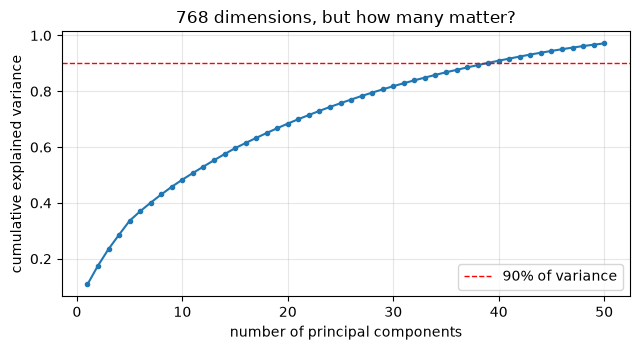

→ ~39 components carry 90% of the variance, not 768.
   Embedding spaces are much 'thinner' than their dimension suggests.


In [8]:
# How many dimensions would we actually need?
full_pca = PCA(n_components=min(50, len(unit) - 1), random_state=RANDOM_STATE).fit(unit)
cumulative = np.cumsum(full_pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker="o", markersize=3)
ax.axhline(0.9, color="red", linestyle="--", linewidth=1, label="90% of variance")
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative explained variance")
ax.set_title("768 dimensions, but how many matter?")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

needed = int(np.searchsorted(cumulative, 0.9) + 1)
print(f"→ ~{needed} components carry 90% of the variance, not 768.")
print("   Embedding spaces are much 'thinner' than their dimension suggests.")

## 4 · UMAP the one that makes the poster

UMAP builds a graph of each point's **nearest neighbours** and lays that graph
out in 2D, trying to keep neighbours together. It is non-linear, so it can
unfold structure PCA flattens. That's why it separates clusters so crisply.

The price, and you must know it before you put one in a paper:

* **Distances between clusters are not trustworthy.** Two blobs being far
  apart on a UMAP plot says almost nothing about how far apart they are really.
* **Cluster sizes are not trustworthy** either.
* **It is stochastic and hyperparameter-sensitive.** `n_neighbors` trades
  local for global structure; change it and the picture changes.
* **UMAP will happily show you clusters in pure noise.** Always sanity-check
  against a numeric measure (section 5) or a random-label control.

In [9]:
import warnings

import umap

warnings.filterwarnings("ignore", category=UserWarning)

with timer("UMAP"):
    reducer = umap.UMAP(
        n_neighbors=10,      # ↑ = more global structure, ↓ = more local detail
        min_dist=0.1,        # how tightly points may pack together
        metric="cosine",     # the right metric for text embeddings
        random_state=RANDOM_STATE,
    )
    umap_points = reducer.fit_transform(unit)

/home/sofiane/miniconda3/envs/imprs_workshop/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


[UMAP: 7.09s]


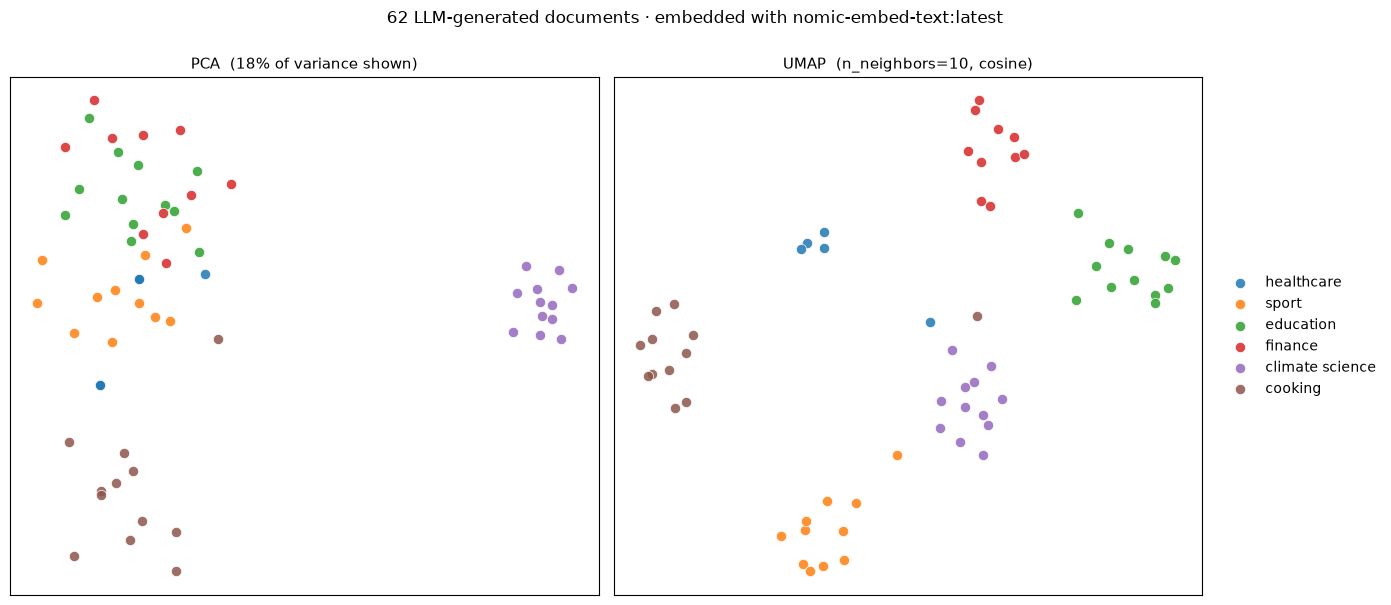

Same data, same embeddings, two very different pictures.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter(pca_points, f"PCA  ({explained.sum():.0%} of variance shown)", axes[0])
scatter(umap_points, "UMAP  (n_neighbors=10, cosine)", axes[1])
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle(f"{len(corpus)} LLM-generated documents · embedded with {EMBED_MODEL}", y=1.0)
plt.tight_layout()
plt.savefig(DATA_DIR / "semantic_map.png", dpi=120, bbox_inches="tight")
plt.show()

print("Same data, same embeddings, two very different pictures.")

### Feel the hyperparameter

Run the sweep below and watch the *same data* reorganise itself. If a
conclusion of yours survives only one setting of `n_neighbors`, it is not a
conclusion.

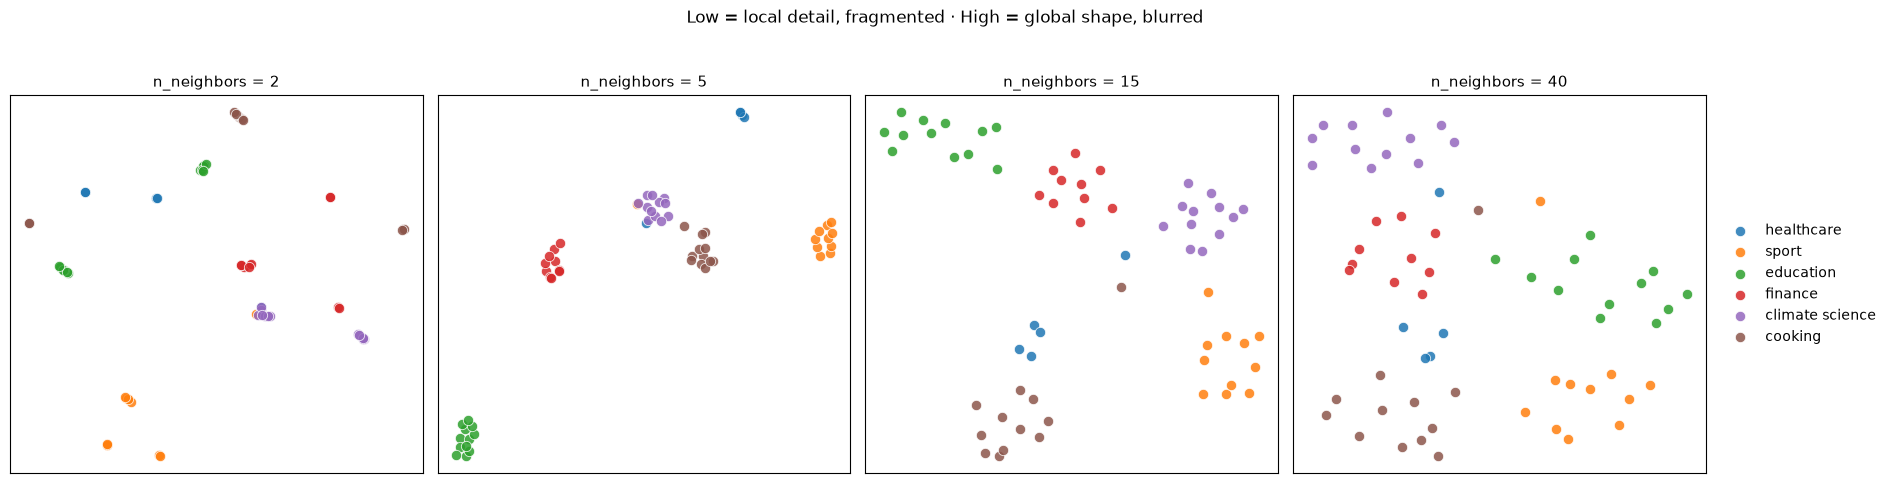

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.6))
for ax, n_neighbors in zip(axes, [2, 5, 15, 40]):
    points = umap.UMAP(
        n_neighbors=n_neighbors, min_dist=0.1, metric="cosine", random_state=RANDOM_STATE
    ).fit_transform(unit)
    scatter(points, f"n_neighbors = {n_neighbors}", ax)
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.suptitle("Low = local detail, fragmented · High = global shape, blurred", y=1.04)
plt.tight_layout()
plt.show()

## 5 · Don't trust your eyes measure it

Two cheap, honest checks on whether the categories are *really* separated in
the **original 768-D space** (not in the projection).

In [12]:
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

# (a) Average within-category vs between-category similarity.
similarity = sk_cosine(unit)
same_category = labels[:, None] == labels[None, :]
off_diagonal = ~np.eye(len(labels), dtype=bool)

within = similarity[same_category & off_diagonal].mean()
between = similarity[~same_category].mean()

print(f"mean cosine within a category : {within:.4f}")
print(f"mean cosine between categories: {between:.4f}")
print(f"separation                    : {within - between:+.4f}  (want clearly > 0)")

mean cosine within a category : 0.5889
mean cosine between categories: 0.4308
separation                    : +0.1581  (want clearly > 0)


In [13]:
# (b) Neighbour purity: of each document's 5 nearest neighbours, how many share
# its category? This is exactly the question a retriever asks, so it is the
# most operationally relevant number on this page.
K = 5
np.fill_diagonal(similarity, -np.inf)             # never your own neighbour
neighbours = np.argsort(-similarity, axis=1)[:, :K]
purity = (labels[neighbours] == labels[:, None]).mean(axis=1)

per_category = (
    pd.DataFrame({"category": labels, "purity": purity})
    .groupby("category").purity.mean().sort_values(ascending=False)
)
print(f"top-{K} neighbour purity per category (1.0 = perfect):\n")
print(per_category.round(3).to_string())
print(f"\noverall: {purity.mean():.3f}   (random baseline ≈ {1 / len(CATEGORIES):.3f})")

top-5 neighbour purity per category (1.0 = perfect):

category
climate science    1.000
education          0.900
finance            0.840
cooking            0.817
sport              0.800
healthcare         0.560

overall: 0.848   (random baseline ≈ 0.167)


In [14]:
# (c) Which documents are confusing? These are the ones to read by hand --
# usually either genuinely ambiguous, or a generation slip by the LLM.
confusing = pd.DataFrame(
    {"category": labels, "purity": purity, "text": corpus.text}
).nsmallest(5, "purity")

print("Least 'pure' documents — read these, they teach you about your data:\n")
for _, row in confusing.iterrows():
    print(f"[{row.category:<16} purity={row.purity:.2f}] {row.text[:100]}")

Least 'pure' documents — read these, they teach you about your data:

[cooking          purity=0.20] Foamy bits form naturally on top as proteins collapse, signaling doneness without checking constantl
[healthcare       purity=0.40] Radiology scans revealed early signs that could have prevented a future complication,
[sport            purity=0.40] A marathon runner beats his own personal record today.
[finance          purity=0.40] Stocks can soar rapidly if company earnings turn out to be higher than expected.
[healthcare       purity=0.60] A nurse checks vital signs on every patient during their morning shift.


### Category centroids: which topics live near each other?

Averaging all vectors of a category gives a "prototype" for it. Comparing
prototypes is a nice macro view and this *is* interpretable, unlike the
distances in the UMAP plot.

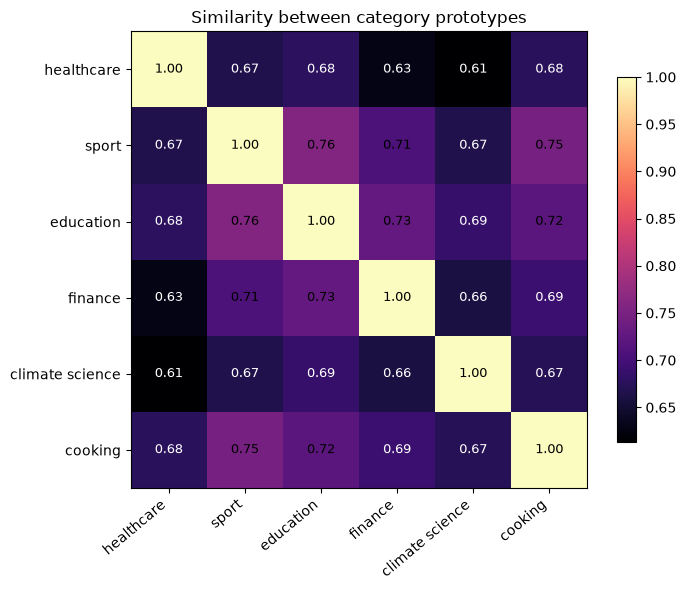

In [15]:
centroids = np.stack([unit[labels == c].mean(axis=0) for c in CATEGORIES])
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)
centroid_similarity = pd.DataFrame(
    sk_cosine(centroids).round(3), index=CATEGORIES, columns=CATEGORIES
)

fig, ax = plt.subplots(figsize=(7.5, 6))
image = ax.imshow(centroid_similarity, cmap="magma")
ax.set_xticks(range(len(CATEGORIES)), CATEGORIES, rotation=40, ha="right")
ax.set_yticks(range(len(CATEGORIES)), CATEGORIES)
for i in range(len(CATEGORIES)):
    for j in range(len(CATEGORIES)):
        ax.text(j, i, f"{centroid_similarity.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if centroid_similarity.iloc[i, j] < 0.7 else "black", fontsize=9)
ax.set_title("Similarity between category prototypes")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Why this matters for agents

This notebook looks like a data-visualisation detour. It isn't. In notebook 09
a **router agent** has to decide which specialist should handle an incoming
question. One perfectly good way to build that router is: embed the question,
compare it to category centroids, send it to the nearest specialist no LLM
call, no latency, no cost.

You just built the machinery for that.

In [16]:
def route(question: str) -> tuple[str, float]:
    """A zero-LLM router: nearest category prototype wins."""
    vector = np.array(embedder.embed_query(question))
    vector /= np.linalg.norm(vector)
    scores = centroids @ vector
    best = int(np.argmax(scores))
    return CATEGORIES[best], float(scores[best])


for question in [
    "My knee hurts after the marathon, should I see someone?",
    "How do I structure a syllabus for a first-year course?",
    "What happens to bond yields when the central bank raises rates?",
    "How long should I roast a chicken?",
]:
    category, score = route(question)
    print(f"{score:.3f}  {category:<16} ← {question}")

0.575  sport            ← My knee hurts after the marathon, should I see someone?
0.548  education        ← How do I structure a syllabus for a first-year course?
0.619  finance          ← What happens to bond yields when the central bank raises rates?
0.621  cooking          ← How long should I roast a chicken?


Notice the first question is deliberately ambiguous (sport? healthcare?).
Look at the score: a *low* winning score is your signal that the router is
unsure. In a real system that's when you escalate to an LLM router or to a
human. Cheap routing first, expensive routing only when needed.

## Your turn 10 minutes

1. Add a category that **overlaps** an existing one (e.g. `"sports medicine"`
   alongside healthcare and sport). Re-generate with `build_corpus(force=True)`.
   Do the clusters merge? What happens to neighbour purity?
2. Swap `EMBED_MODEL` to `all-minilm:33m` and re-run everything. Is the
   30×-smaller model actually worse *on this task*?
3. Shuffle the labels randomly (`rng.permutation(labels)`) and redraw the UMAP
   plot. The clusters are still there — but now they mean nothing. This is the
   control you should run before believing any embedding plot.

→ Next: **05 · RAG**  we stop *looking* at the vectors and start *using*
them to feed a model facts it was never trained on.